In [83]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import os

Social Data

% UF Sparse Matrix Collection, Tim Davis
% http://www.cise.ufl.edu/research/sparse/matrices/Newman/dolphins
% name: Newman/dolphins
% [social network of dolphins, Doubtful Sound, New Zealand]
% id: 2396
% date: 2003
% author: D. Lusseau
% ed: M. Newman
% fields: name title A id date author kind notes aux ed
% aux: nodename
% kind: undirected graph
%-------------------------------------------------------------------------------
% notes:
% Network collection from M. Newman                                          
% http://www-personal.umich.edu/~mejn/netdata/                               
%                                                                            
% The graph dolphins contains an undirected social network of frequent       
% associations between 62 dolphins in a community living off Doubtful Sound, 
% New Zealand, as compiled by Lusseau et al. (2003).  Please cite            
%                                                                            
%   D. Lusseau, K. Schneider, O. J. Boisseau, P. Haase, E. Slooten, and      
%   S. M. Dawson, The bottlenose dolphin community of Doubtful Sound features
%   a large proportion of long-lasting associations, Behavioral Ecology and  
%   Sociobiology 54, 396-405 (2003).                                         
%                                                                            
% Additional information on the network can be found in                      
%                                                                            
%   D. Lusseau, The emergent properties of a dolphin social network,         
%   Proc. R. Soc. London B (suppl.) 270, S186-S188 (2003).                   
%                                                                            
%   D. Lusseau, Evidence for social role in a dolphin social network,        
%   Preprint q-bio/0607048 (http://arxiv.org/abs/q-bio.PE/0607048)           
%-------------------------------------------------------------------------------

In [84]:
test_data = nx.karate_club_graph()
print(test_data)


bio_SC_TS_data = nx.read_edgelist("C:/Users/Crano/MAT933/Group_Project/core-periphery-detection/data/bio-SC-TS/bio-SC-TS.edges", data=(("weight", float),), create_using=nx.Graph())
Enzymes_data = nx.read_edgelist("C:/Users/Crano/MAT933/Group_Project/core-periphery-detection/data/ENZYMES_g422/ENZYMES_g422.edges", create_using=nx.Graph())
social_data = nx.read_edgelist("C:/Users/Crano/MAT933/Group_Project/core-periphery-detection/data/soc-dolphins/soc-dolphins.edgelist", create_using=nx.Graph())
infection_data = nx.read_edgelist("C:/Users/Crano/MAT933/Group_Project/core-periphery-detection/data/infect-hyper/infect-hyper.edges", create_using=nx.Graph())
technology_data = nx.read_edgelist("C:/Users/Crano/MAT933/Group_Project/core-periphery-detection/data/web-polblogs/web-polblogs.edgelist")
email_data = nx.read_edgelist("C:/Users/Crano/MAT933/Group_Project/core-periphery-detection/data/email-enron-only/email-enron-only.edgelist", create_using=nx.Graph())


Graph named "Zachary's Karate Club" with 34 nodes and 78 edges


In [85]:

bio_SC_TS_louvain = nx.community.louvain_communities(bio_SC_TS_data)
Enzymes_louvain = nx.community.louvain_communities(Enzymes_data)
social_louvain = nx.community.louvain_communities(social_data)
infection_louvain = nx.community.louvain_communities(infection_data)
technology_louvain = nx.community.louvain_communities(technology_data)
email_louvain = nx.community.louvain_communities(email_data )

In [86]:
bio_SC_TS_louvain_dict = {}
Enzymes_louvain_dict = {}
social_louvain_dict = {}
infection_louvain_dict = {}
technology_louvain_dict = {}
email_louvain_dict = {}

dicts = [bio_SC_TS_louvain_dict, Enzymes_louvain_dict, social_louvain_dict,
         infection_louvain_dict, technology_louvain_dict, email_louvain_dict]

louvains = [bio_SC_TS_louvain, Enzymes_louvain, social_louvain,
            infection_louvain, technology_louvain, email_louvain]

for dct, louvain in zip(dicts, louvains):
    for i, group in enumerate(louvain):
        for g in group:
            dct[g] = i


In [87]:
print (len(Enzymes_louvain_dict))

27


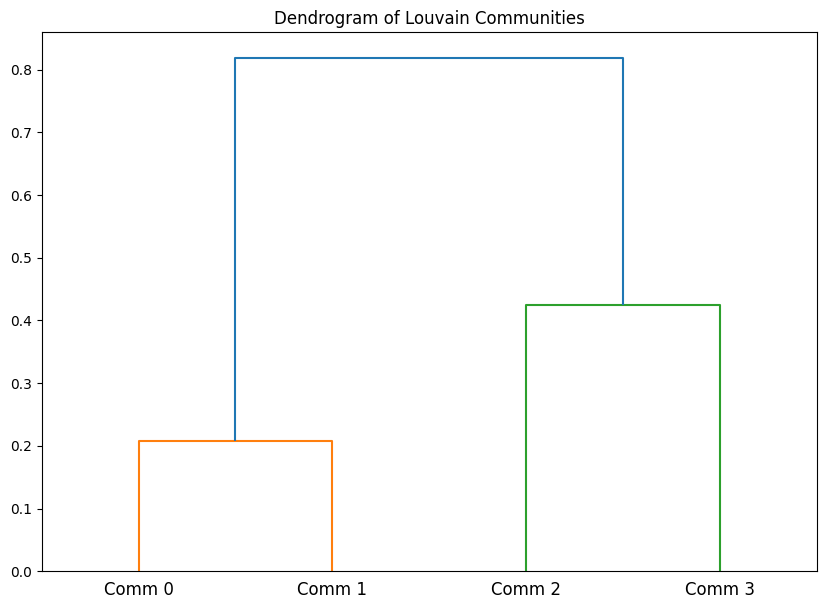

In [88]:
import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# Suppose you have N communities
num_comms = len(set(test_louvain_dict.values()))

# Create a matrix of inter-community edge counts
comm_matrix = np.zeros((num_comms, num_comms))

for u, v in test_data.edges():
    cu, cv = test_louvain_dict[u], test_louvain_dict[v]
    comm_matrix[cu, cv] += 1
    comm_matrix[cv, cu] += 1  # since the graph is undirected

# Convert edge counts to distances
# (high overlap → smaller distance)
dist_matrix = 1 / (comm_matrix + 1)  # add 1 to avoid division by zero

# Perform hierarchical clustering on the communities
Z = linkage(dist_matrix, method='ward')
plt.figure(figsize=(10, 7))
dendrogram(Z, labels=[f"Comm {i}" for i in range(num_comms)])
plt.title("Dendrogram of Louvain Communities")
plt.show()


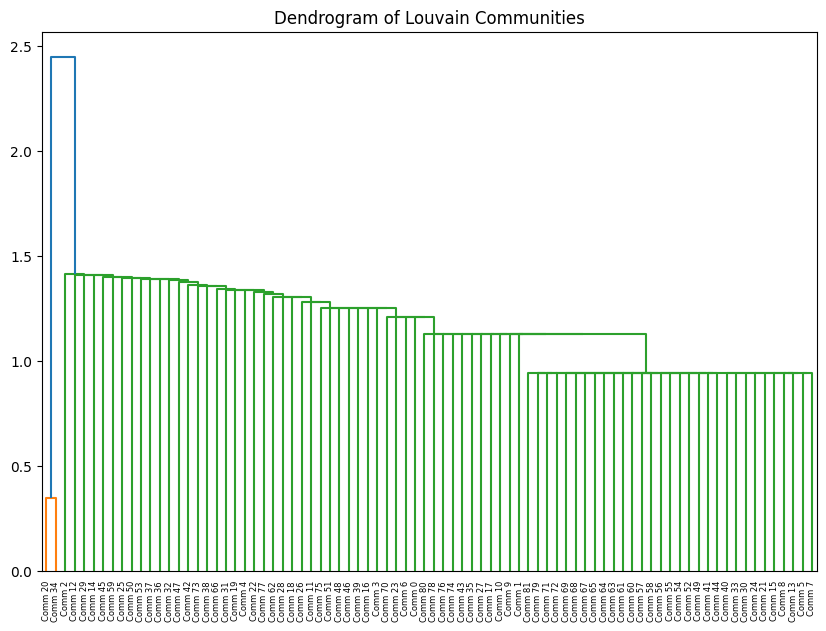

In [89]:
# Suppose you have N communities
num_comms = len(set(bio_SC_TS_louvain_dict.values()))

# Create a matrix of inter-community edge counts
comm_matrix = np.zeros((num_comms, num_comms))

for u, v in bio_SC_TS_data.edges():
    cu, cv = bio_SC_TS_louvain_dict[u], bio_SC_TS_louvain_dict[v]
    comm_matrix[cu, cv] += 1
    comm_matrix[cv, cu] += 1  # since the graph is undirected

# Convert edge counts to distances
# (high overlap → smaller distance)
dist_matrix = 1 / (comm_matrix + 1)  # add 1 to avoid division by zero

# Perform hierarchical clustering on the communities
Z = linkage(dist_matrix, method='ward')
plt.figure(figsize=(10, 7))
dendrogram(Z, labels=[f"Comm {i}" for i in range(num_comms)])
plt.title("Dendrogram of Louvain Communities")
plt.show() 

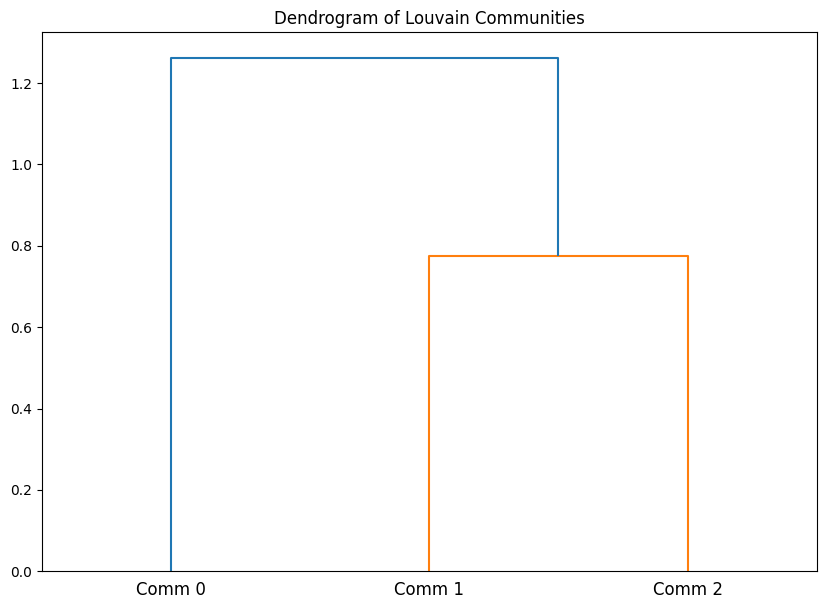

In [90]:
# Suppose you have N communities
num_comms = len(set(Enzymes_louvain_dict.values()))

# Create a matrix of inter-community edge counts
comm_matrix = np.zeros((num_comms, num_comms))

for u, v in Enzymes_data.edges():
    cu, cv = Enzymes_louvain_dict[u], Enzymes_louvain_dict[v]
    comm_matrix[cu, cv] += 1
    comm_matrix[cv, cu] += 1  # since the graph is undirected
    

# Convert edge counts to distances
# (high overlap → smaller distance)
dist_matrix = 1 / (comm_matrix + 1)  # add 1 to avoid division by zero

# Perform hierarchical clustering on the communities
Z = linkage(dist_matrix, method='ward')
plt.figure(figsize=(10, 7))
dendrogram(Z, labels=[f"Comm {i}" for i in range(num_comms)])
plt.title("Dendrogram of Louvain Communities")
plt.show()

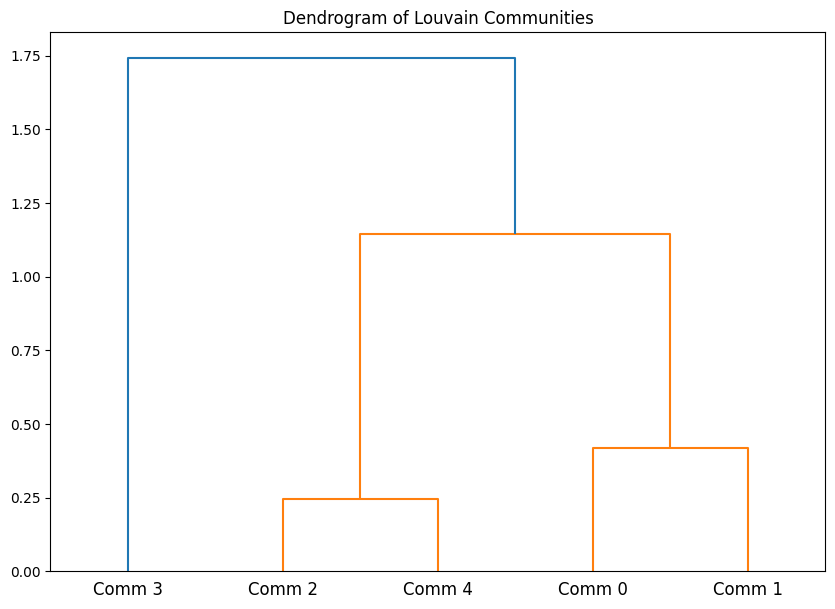

In [91]:
# Suppose you have N communities
num_comms = len(set(social_louvain_dict.values()))

# Create a matrix of inter-community edge counts
comm_matrix = np.zeros((num_comms, num_comms))

for u, v in social_data.edges():
    cu, cv = social_louvain_dict[u], social_louvain_dict[v]
    comm_matrix[cu, cv] += 1
    comm_matrix[cv, cu] += 1  # since the graph is undirected

# Convert edge counts to distances
# (high overlap → smaller distance)
dist_matrix = 1 / (comm_matrix + 1)  # add 1 to avoid division by zero

# Perform hierarchical clustering on the communities
Z = linkage(dist_matrix, method='ward')
plt.figure(figsize=(10, 7))
dendrogram(Z, labels=[f"Comm {i}" for i in range(num_comms)])
plt.title("Dendrogram of Louvain Communities")
plt.show()

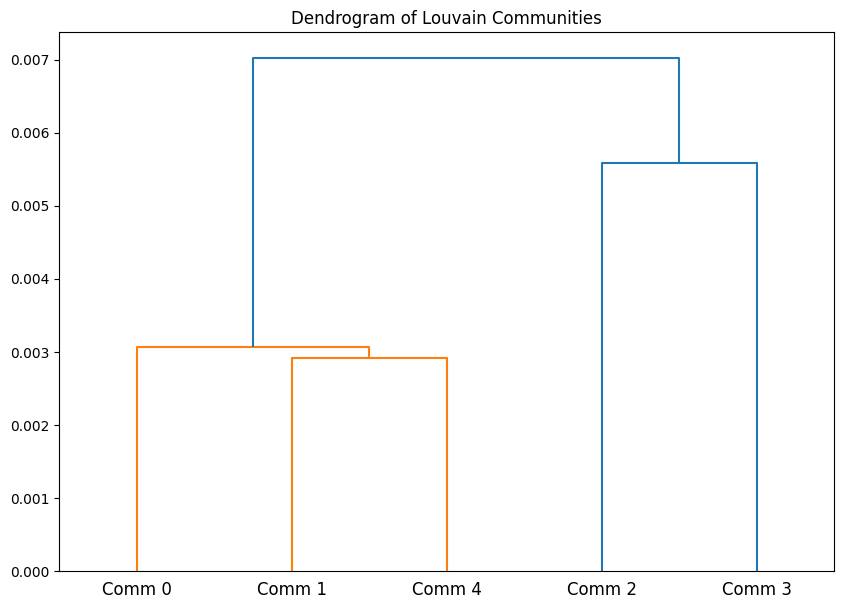

In [92]:
# Suppose you have N communities
num_comms = len(set(infection_louvain_dict.values()))

# Create a matrix of inter-community edge counts
comm_matrix = np.zeros((num_comms, num_comms))

for u, v in infection_data.edges():
    cu, cv = infection_louvain_dict[u], infection_louvain_dict[v]
    comm_matrix[cu, cv] += 1
    comm_matrix[cv, cu] += 1  # since the graph is undirected

# Convert edge counts to distances
# (high overlap → smaller distance)
dist_matrix = 1 / (comm_matrix + 1)  # add 1 to avoid division by zero

# Perform hierarchical clustering on the communities
Z = linkage(dist_matrix, method='ward')
plt.figure(figsize=(10, 7))
dendrogram(Z, labels=[f"Comm {i}" for i in range(num_comms)])
plt.title("Dendrogram of Louvain Communities")
plt.show()

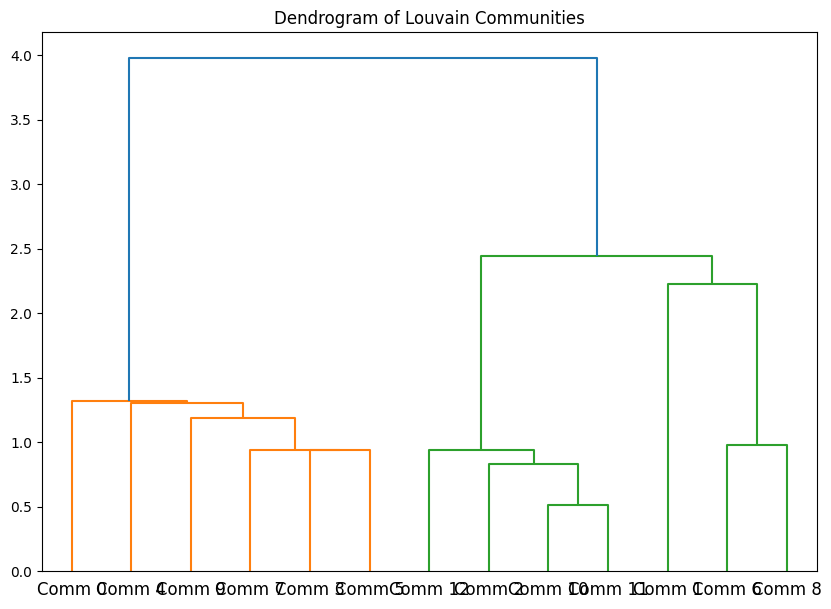

In [93]:
# Suppose you have N communities
num_comms = len(set(technology_louvain_dict.values()))

# Create a matrix of inter-community edge counts
comm_matrix = np.zeros((num_comms, num_comms))

for u, v in technology_data.edges():
    cu, cv = technology_louvain_dict[u], technology_louvain_dict[v]
    comm_matrix[cu, cv] += 1
    comm_matrix[cv, cu] += 1  # since the graph is undirected

# Convert edge counts to distances
# (high overlap → smaller distance)
dist_matrix = 1 / (comm_matrix + 1)  # add 1 to avoid division by zero

# Perform hierarchical clustering on the communities
Z = linkage(dist_matrix, method='ward')
plt.figure(figsize=(10, 7))
dendrogram(Z, labels=[f"Comm {i}" for i in range(num_comms)])
plt.title("Dendrogram of Louvain Communities")
plt.show()

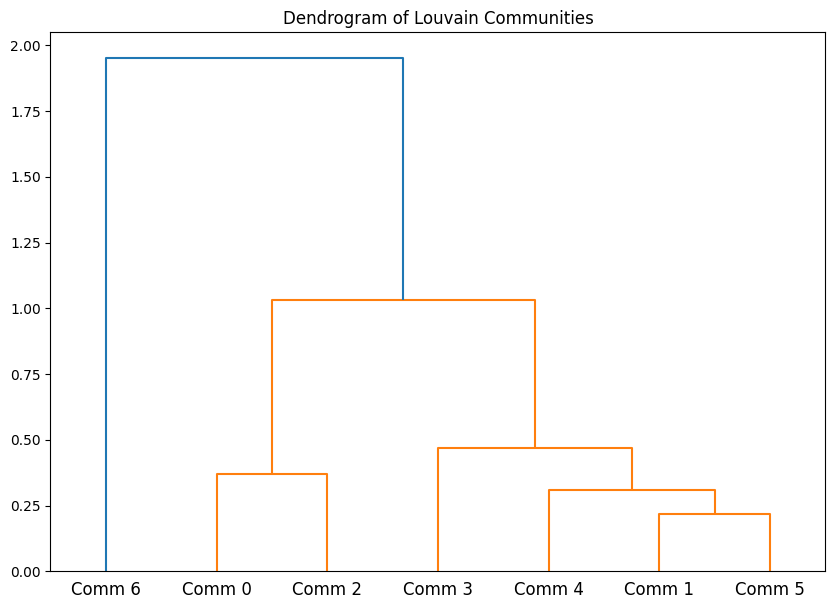

In [94]:
# Suppose you have N communities
num_comms = len(set(email_louvain_dict.values()))

# Create a matrix of inter-community edge counts
comm_matrix = np.zeros((num_comms, num_comms))

for u, v in email_data.edges():
    cu, cv = email_louvain_dict[u], email_louvain_dict[v]
    comm_matrix[cu, cv] += 1
    comm_matrix[cv, cu] += 1  # since the graph is undirected

# Convert edge counts to distances
# (high overlap → smaller distance)
dist_matrix = 1 / (comm_matrix + 1)  # add 1 to avoid division by zero

# Perform hierarchical clustering on the communities
Z = linkage(dist_matrix, method='ward')
plt.figure(figsize=(10, 7))
dendrogram(Z, labels=[f"Comm {i}" for i in range(num_comms)])
plt.title("Dendrogram of Louvain Communities")
plt.show()

In [97]:
print(bio_SC_TS_data)

Graph with 636 nodes and 3959 edges


In [ ]:
def export_communities_to_gexf(G, community_dict, output_file):
    """
    Assigns community IDs as node attributes and exports the graph to a GEXF file.
    """
    # 1️⃣ Assign community as a node attribute
    for node, comm in community_dict.items():
        if node in G:
            G.nodes[node]['community'] = int(comm)  # ensure it's serializable

    # 2️⃣ Ensure the output directory exists
    os.makedirs(os.path.dirname(output_file) or ".", exist_ok=True)

    # 3️⃣ Save to GEXF safely
    try:
        nx.write_gexf(G, output_file)
        print(f"✅ Graph with communities saved to: {output_file}")
    except Exception as e:
        print(f"⚠️ Error saving {output_file}: {e}")
export_communities_to_gexf(bio_SC_TS_data, bio_SC_TS_louvain_dict, "output/bio_SC_TS_communities.gexf")
export_communities_to_gexf(Enzymes_data, Enzymes_louvain_dict, "output/Enzymes_communities.gexf")
export_communities_to_gexf(social_data, social_louvain_dict, "output/social_communities.gexf")
export_communities_to_gexf(infection_data, infection_louvain_dict, "output/infection_communities.gexf")
export_communities_to_gexf(technology_data, technology_louvain_dict, "output/technology_communities.gexf")
export_communities_to_gexf(email_data, email_louvain_dict, "output/email_communities.gexf")




✅ Graph with communities saved to: C:/Users/Crano/MAT933/Group_Project/core-periphery-detection/dataoutput/bio_SC_TS_communities.gexf
✅ Graph with communities saved to: C:/Users/Crano/MAT933/Group_Project/core-periphery-detection/dataoutput/Enzymes_communities.gexf
✅ Graph with communities saved to: C:/Users/Crano/MAT933/Group_Project/core-periphery-detection/dataoutput/social_communities.gexf
✅ Graph with communities saved to: C:/Users/Crano/MAT933/Group_Project/core-periphery-detection/dataoutput/infection_communities.gexf
✅ Graph with communities saved to: C:/Users/Crano/MAT933/Group_Project/core-periphery-detection/dataoutput/technology_communities.gexf
✅ Graph with communities saved to: C:/Users/Crano/MAT933/Group_Project/core-periphery-detection/dataoutput/email_communities.gexf
